# OASIS INFOBYTE - Data Analytics Internship

## Level 1 - Task 1: EDA on Retail Sales Data

### Objective
Perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover:
- Sales trends
- Customer behaviour
- Demographic patterns
- Product performance
- Relationships between numerical variables
- Actionable business insights

### Dataset
The dataset contains retail transaction records with information about:
- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("Sales_Data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df = pd.read_csv(r"D:\OIBSIP\DataAnalytics-L1-EDARetailSales\Sales_Data.csv")

In [4]:
# Display first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
# Display last 5 rows
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [6]:
# Dataset dimensions
rows, columns = df.shape

print(f"Number of rows    : {rows}")
print(f"Number of columns : {columns}")

Number of rows    : 1000
Number of columns : 9


In [7]:
# Column names
print("Column Names:")
for column in df.columns:
    print("-", column)

Column Names:
- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount


In [8]:
# Data types
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
# Missing values in each column
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [11]:
# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_report

,Missing Values,Missing Percentage
Transaction ID,0,0.0
Date,0,0.0
Customer ID,0,0.0
Gender,0,0.0
Age,0,0.0
Product Category,0,0.0
Quantity,0,0.0
Price per Unit,0,0.0
Total Amount,0,0.0


### Observation

The dataset contains no missing values in any of the nine columns. Therefore, no missing-value imputation or row deletion is required at this stage.

In [12]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [13]:
if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records are present.")

No duplicate records found.


### Observation

Duplicate records were checked to ensure that the same transaction was not accidentally recorded multiple times. The duplicate count will be used to determine whether any records need to be removed during data cleaning.

In [14]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check the result
print(df["Date"].dtype)

datetime64[ns]


In [15]:
# Check whether date conversion created any missing values
print("Invalid dates:", df["Date"].isnull().sum())

Invalid dates: 0


### Observation

The `Date` column was converted from a text/object data type to `datetime`. This allows us to perform time-based analysis such as monthly and quarterly sales trend analysis.

In [16]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


In [17]:
# Descriptive statistics
descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics - Observations

The descriptive statistics provide an overview of transaction, customer, quantity, pricing, and revenue-related variables.

- **Mean** represents the average value.
- **Median** represents the middle value and is useful for understanding the central tendency.
- **Mode** represents the most frequently occurring value.
- **Standard deviation** measures the spread or variability of the data.

Comparing the mean and median can also help identify whether certain numerical variables have skewed distributions.

In [19]:
# Unique product categories
print("Product Categories:")
print(df["Product Category"].unique())

Product Categories:
['Beauty' 'Clothing' 'Electronics']


In [20]:
# Number of transactions by product category
category_counts = df["Product Category"].value_counts()

category_counts

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [21]:
# Extract month and month name
df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Total Amount"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

monthly_sales

,Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


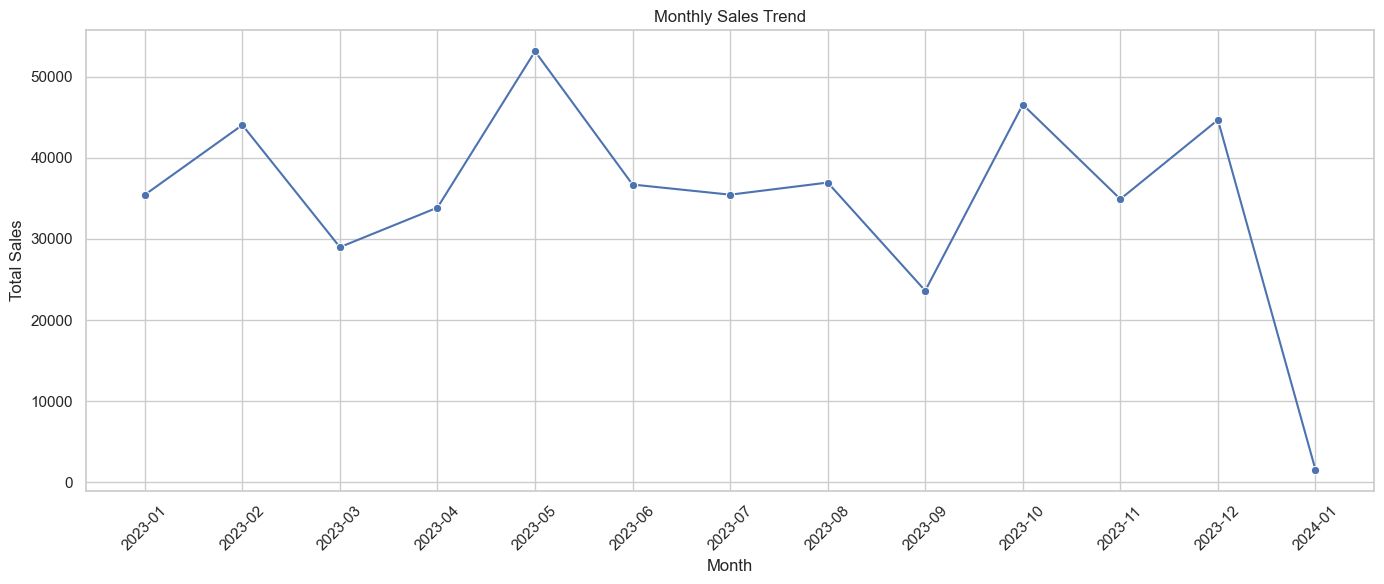

In [22]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows how total revenue changes over time. Peaks indicate months with relatively higher sales, while declines indicate periods of lower sales.

This analysis can help a business identify seasonal patterns and plan inventory, staffing, and marketing campaigns accordingly.

In [23]:
# Extract quarter
df["Quarter"] = df["Date"].dt.to_period("Q")

quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
    .sum()
    .reset_index()
)

quarterly_sales["Quarter"] = quarterly_sales["Quarter"].astype(str)

quarterly_sales

,Quarter,Total Amount
0,2023Q1,108500
1,2023Q2,123735
2,2023Q3,96045
3,2023Q4,126190
4,2024Q1,1530


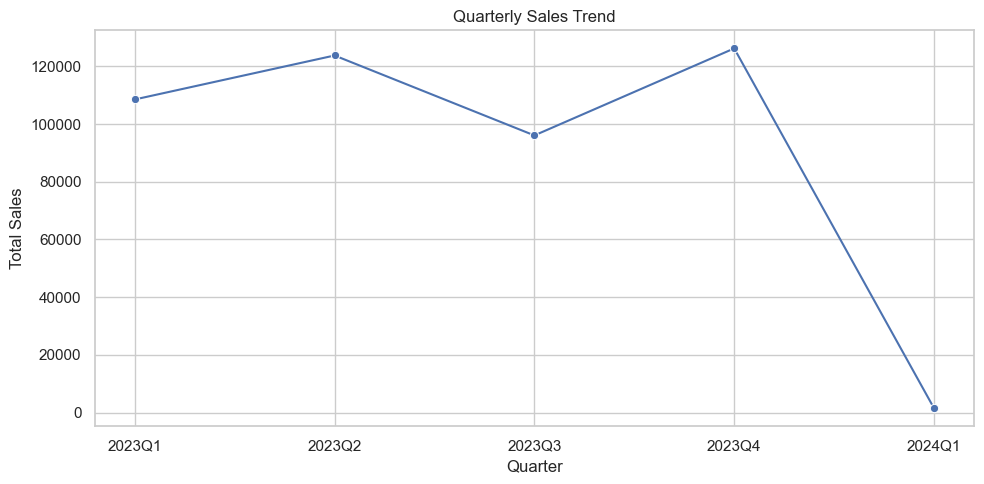

In [24]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=quarterly_sales,
    x="Quarter",
    y="Total Amount",
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Observation

The quarterly sales analysis provides a broader view of business performance than the monthly analysis. Comparing quarters helps identify periods of stronger or weaker overall revenue performance and can support quarterly business planning.

In [25]:
# Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

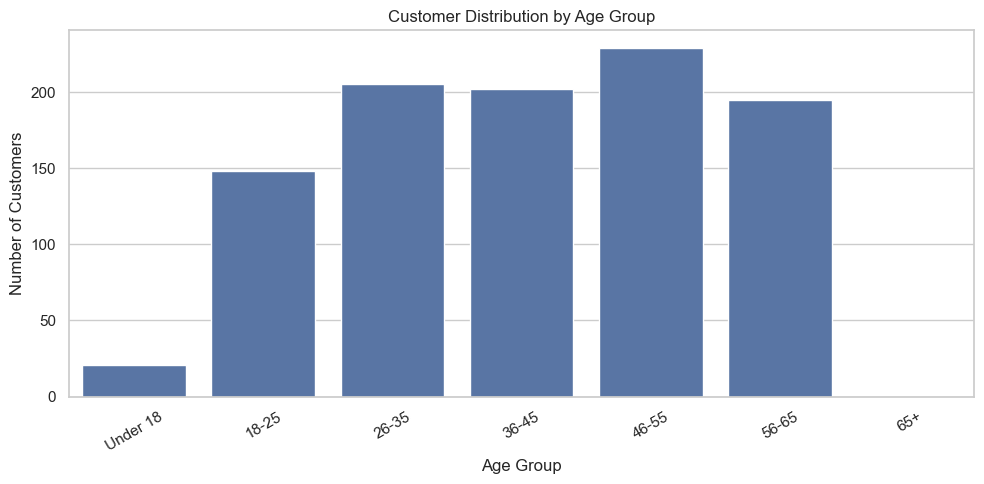

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation

The age-group distribution shows which customer age segments contribute the largest number of transactions.

Understanding the dominant age groups can help the business tailor product recommendations, advertising messages, and promotional campaigns to its primary customer segments.

In [27]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

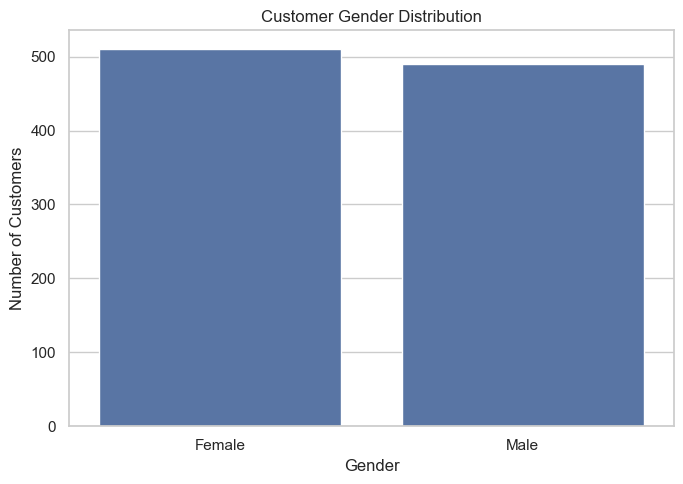

In [28]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Observation

The gender distribution shows the proportion of transactions associated with each gender category. This information can help evaluate whether purchasing activity is relatively balanced or concentrated within a particular customer group.

In [29]:
top_products = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

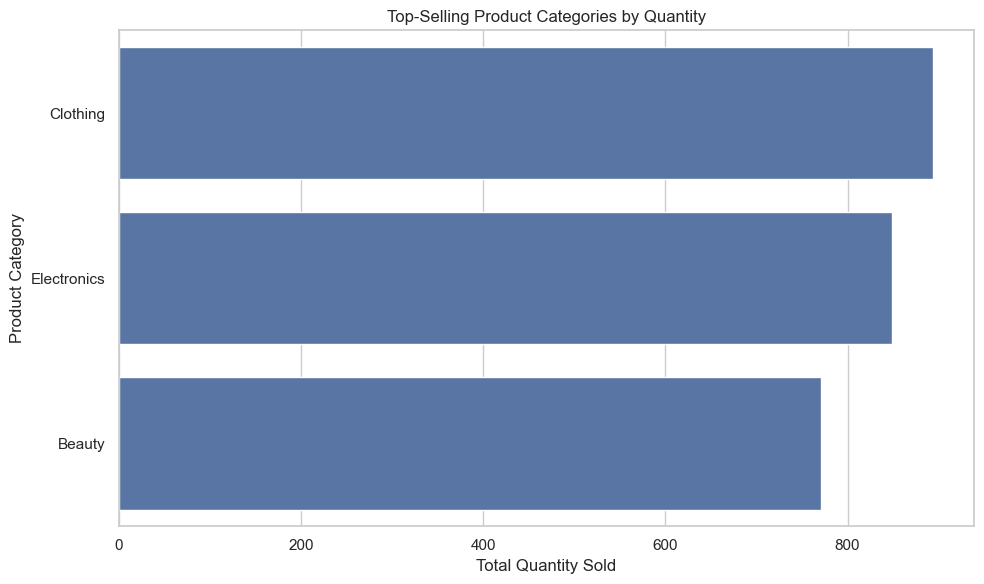

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top-Selling Product Categories by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Observation

The chart identifies the product categories with the highest sales volume based on quantity sold.

Categories with higher quantities may represent products with stronger customer demand. These categories should be monitored closely for inventory planning and promotional opportunities.

In [31]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

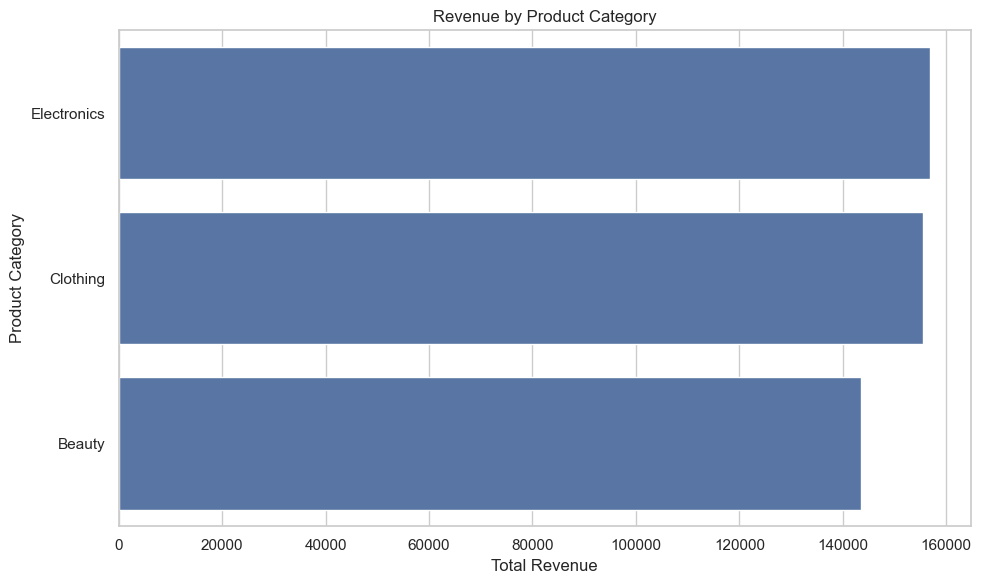

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Observation

Revenue varies across product categories. A category can generate high revenue either because it has high sales volume, higher-priced products, or a combination of both.

Revenue by category is useful for identifying major contributors to overall business revenue and supporting product portfolio decisions.

In [33]:
# Select numerical columns
correlation_data = df.select_dtypes(include=np.number)

correlation_matrix = correlation_data.corr()

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


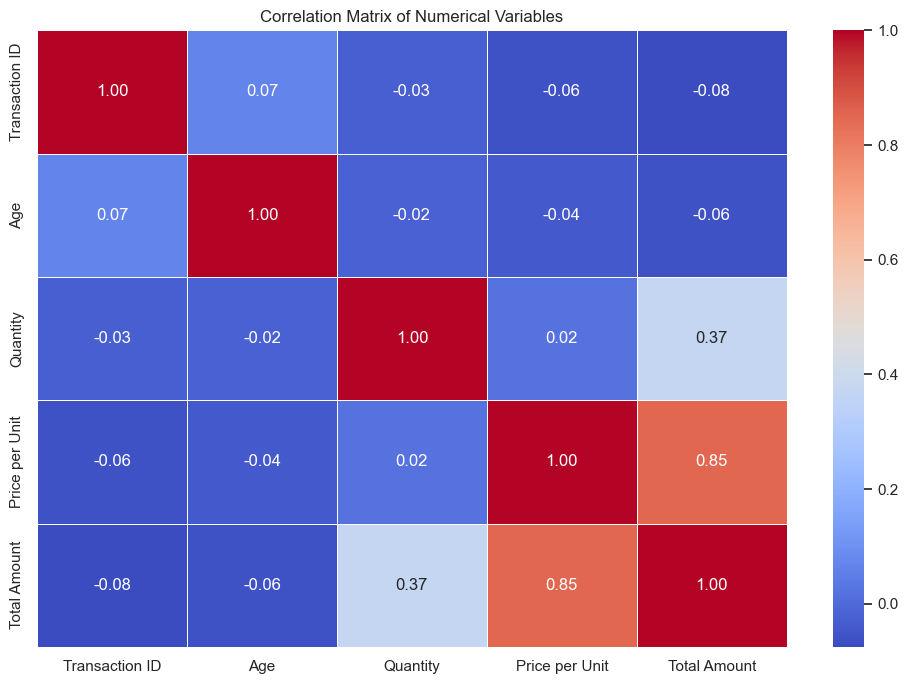

In [34]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables.

A correlation close to **+1** indicates a strong positive relationship, while a value close to **-1** indicates a strong negative relationship. Values near **0** indicate a weak linear relationship.

The relationship between `Quantity`, `Price per Unit`, and `Total Amount` is particularly useful because total transaction revenue is influenced by the quantity purchased and unit price.

In [35]:
average_amount_by_age = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .mean()
    .sort_values(ascending=False)
)

average_amount_by_age

Age Group
Under 18    534.047619
18-25       495.506757
26-35       480.390244
36-45       454.801980
46-55       439.694323
56-65       412.358974
65+                NaN
Name: Total Amount, dtype: float64

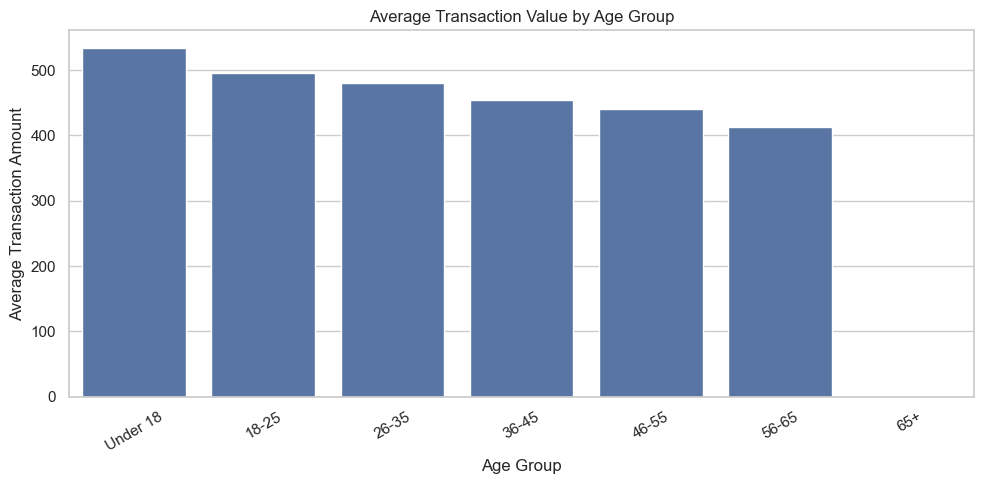

In [36]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=average_amount_by_age.index,
    y=average_amount_by_age.values
)

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Additional Insight

The average transaction value by age group provides a different perspective from simply counting customers.

A smaller age group may generate relatively high-value transactions even if it has fewer transactions overall. Therefore, customer count alone should not be used to determine the commercial importance of a customer segment.

This insight can help businesses distinguish between **high-volume customer segments** and **high-value customer segments**.

In [37]:
total_revenue = df["Total Amount"].sum()
total_transactions = df["Transaction ID"].nunique()
total_quantity = df["Quantity"].sum()
average_transaction_value = df["Total Amount"].mean()

print(f"Total Revenue              : {total_revenue:,.2f}")
print(f"Total Transactions         : {total_transactions:,}")
print(f"Total Quantity Sold        : {total_quantity:,}")
print(f"Average Transaction Value  : {average_transaction_value:,.2f}")

Total Revenue              : 456,000.00
Total Transactions         : 1,000
Total Quantity Sold        : 2,514
Average Transaction Value  : 456.00


## Key Business Metrics

The key metrics provide a high-level summary of the retail business:

- **Total Revenue:** Overall revenue generated by the transactions.
- **Total Transactions:** Number of unique transactions recorded.
- **Total Quantity Sold:** Total units purchased.
- **Average Transaction Value:** Average revenue generated per transaction.

These metrics can serve as baseline KPIs for monitoring future sales performance.

# Conclusion

The Exploratory Data Analysis of the retail sales dataset provided insights into sales trends, customer demographics, product-category performance, and relationships between numerical variables.

The analysis covered monthly and quarterly sales trends, customer age groups, gender distribution, product-category sales, revenue contribution, correlation between numerical variables, and average transaction value across age groups.

The analysis demonstrates that retail decision-making should consider multiple dimensions of the data rather than relying on a single metric. Sales volume, revenue, customer demographics, transaction value, and time-based trends can collectively support better inventory planning, marketing strategies, and customer targeting.

### Key Takeaways

1. Sales trends can help identify periods of stronger and weaker business performance.
2. Customer demographic analysis provides useful information for targeted marketing.
3. Product-category revenue and quantity analysis helps identify important areas of the product portfolio.
4. Average transaction value provides additional insight into customer segment value.
5. Correlation analysis helps identify relationships between numerical business variables.

Overall, the EDA provides a data-driven foundation for making informed retail business decisions.